<a href="https://colab.research.google.com/github/RahulSwami151/Celebal_2027/blob/main/week3%3CRahul_swami%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AIM :** Developed an end-to-end Country rescuing by HELP International using  clustering (K-Means, DBSCAN), achieving optimized predictive performance and to categorise the countries using socio-economic and health factors that determine the overall development of the country.


# **Installing required Libraries ⬇**



In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN,KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Country-data.csv')

# **Data Preprocessing ⬇**

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.shape

(167, 10)

In [7]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# **EDA ⬇**

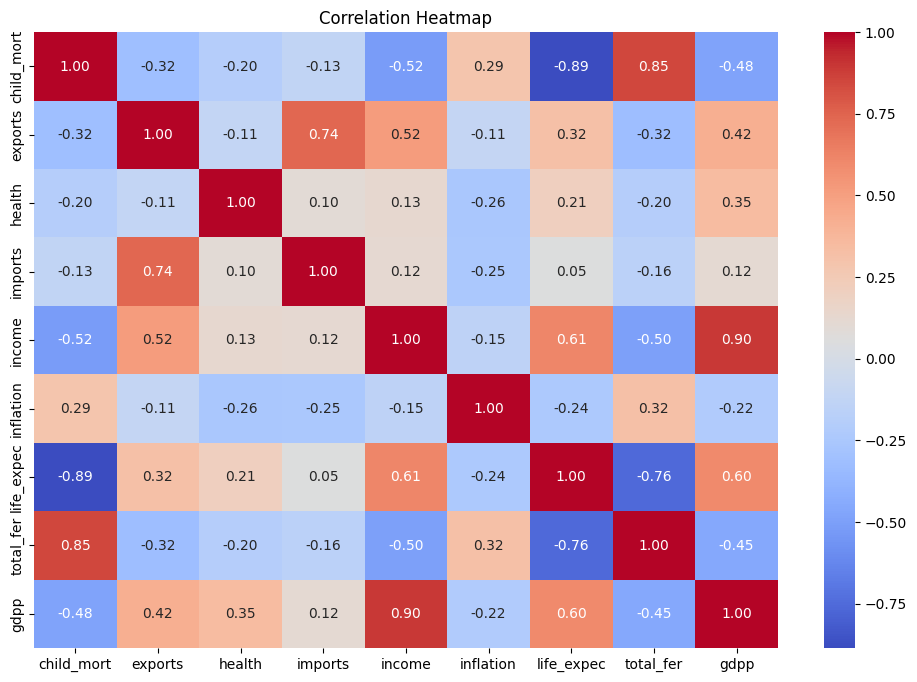

In [8]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

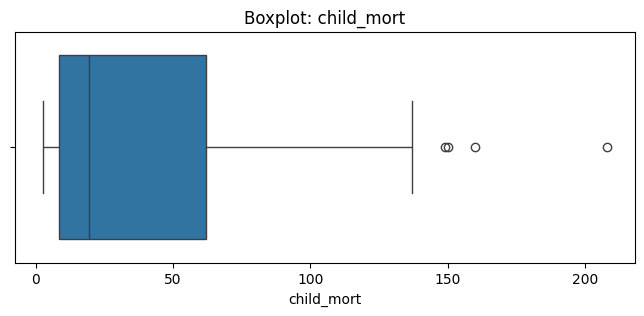

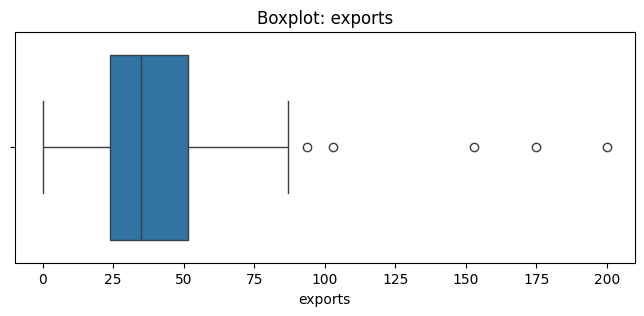

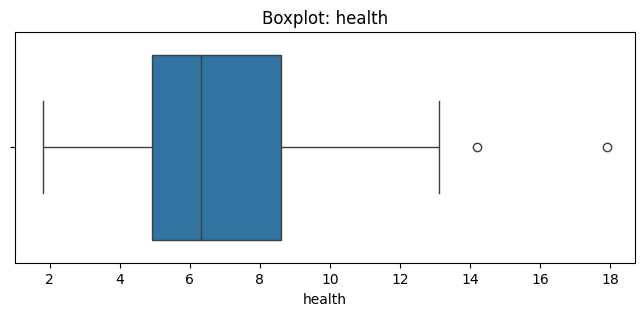

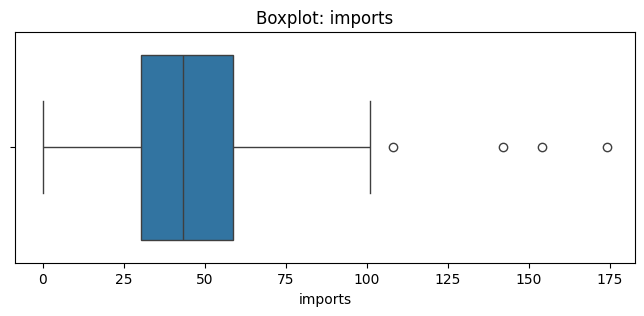

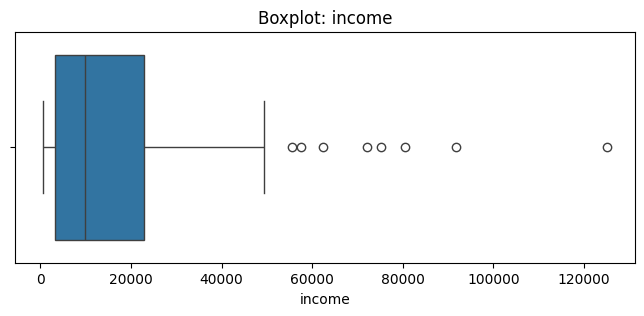

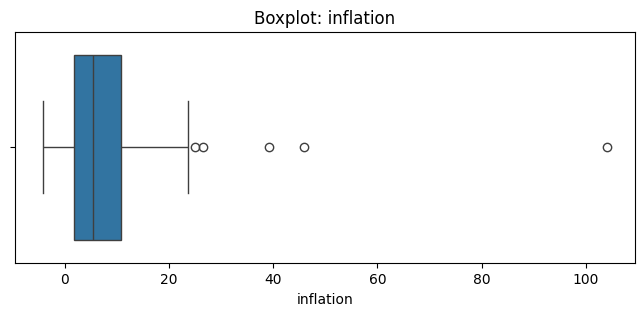

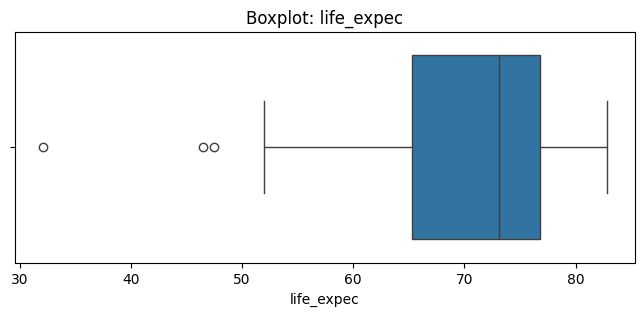

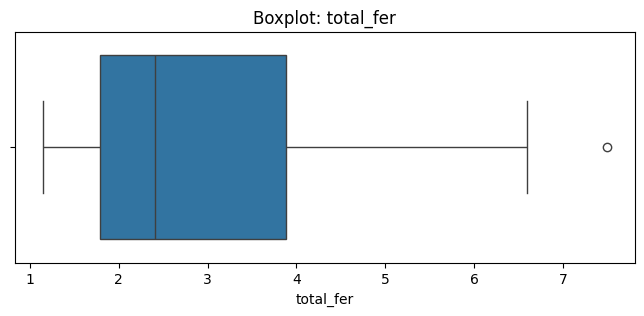

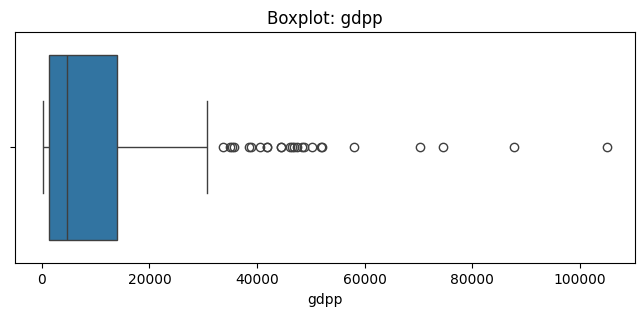

In [9]:
numeric_cols = df.drop(columns='country')

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

NOTE: now we know data is having outliers but due to shortage of data we dont remove them or clip them because we then use dbscan which is Robust to outlier it will handle them for now we are living them as it is.


# **Standard Scaler**

In [10]:
X = df.drop(columns='country',errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

# **K-Means Clustering**

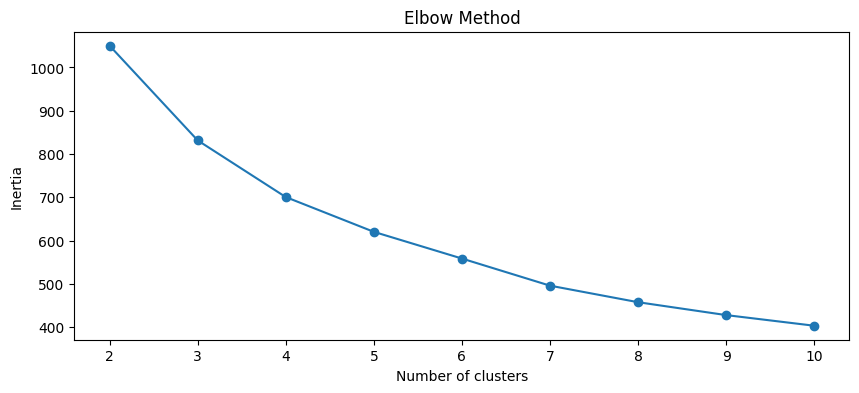

In [12]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [13]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


In [14]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


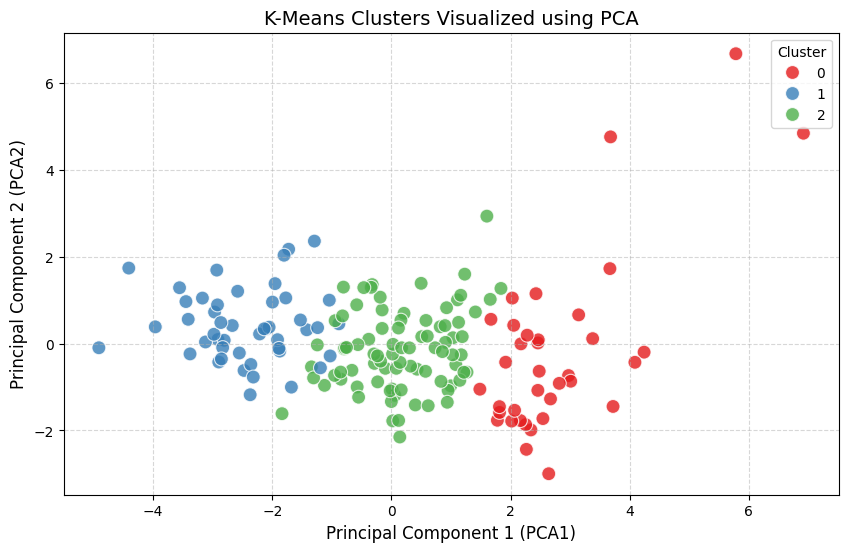

In [15]:
df_kmeans =df.copy()
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_kmeans['pca1'] = X_pca[:, 0]
df_kmeans['pca2'] = X_pca[:, 1]

# 3. Plot the PCA components
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_kmeans,
    x='pca1',
    y='pca2',
    hue='kmeans_cluster',
    palette='Set1',
    s=100,
    alpha=0.8
)

# Labeling the PCA chart
plt.title('K-Means Clusters Visualized using PCA', fontsize=14)
plt.xlabel('Principal Component 1 (PCA1)', fontsize=12)
plt.ylabel('Principal Component 2 (PCA2)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **DBSCAN**

In [27]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


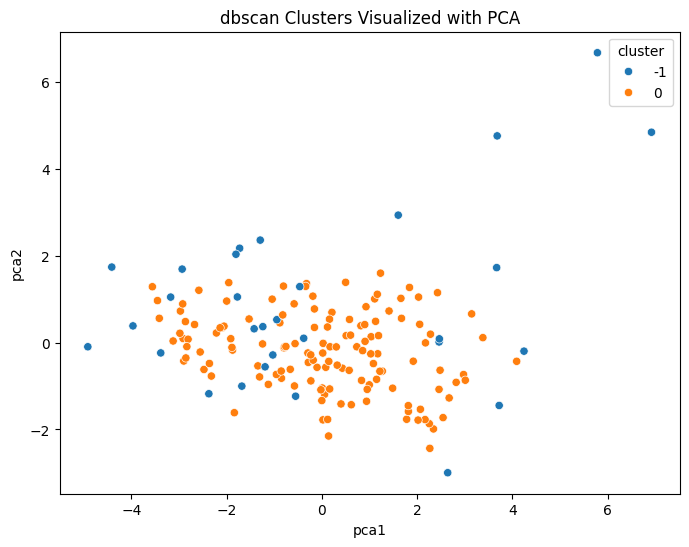

In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['dbscan_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('dbscan Clusters Visualized with PCA')
plt.show()

# **Final Interpretations & Key Observations**

**Based on the end-to-end clustering results generated by K-Means ($K=3$) and mapped via PCA, the 167 countries have been cleanly partitioned into three actionable socio-economic profiles:**


Cluster 1 — Low-Development / High-Priority Rescue Zone:
This cluster isolates countries facing severe structural and humanitarian crises, explicitly exemplified by Afghanistan and Angola. These nations are characterized by dangerously high child mortality rates (e.g., Afghan child mortality at 90.2 and Angola at 119.0) paired with exceptionally low net income per person and low GDP per capita. This is the primary target group requiring immediate intervention and aid distribution from HELP International.

Cluster 2 — Developing / Mid-Tier Economic Zone:
This major cluster represents transitioning economies showing moderate development metrics, including Albania, Algeria, and Antigua and Barbuda. These countries exhibit significantly improved life expectancies (averaging over 70+ years) and lower inflation/child mortality compared to Cluster 1. They represent stable, developing regions that require structural development support rather than emergency humanitarian aid.

Cluster 0 — Top-Tier / Advanced Economic Zone:
Though not visible in the early .head() printouts, K-Means successfully separated the highly advanced global economies into a distinct cluster. These nations feature elite socio-economic indicators: low child mortality rates (typically single digits), high life expectancy, and substantial GDP per capita (gdpp) alongside high net income.

DBSCAN Outlier Insights (-1 Label):
When cross-referencing with our DBSCAN model, the 30 countries flagged as noise (-1) represent extreme statistical anomalies. These are either hyper-wealthy financial hubs (e.g., countries with outlying gdpp and exports columns) or nations undergoing temporary hyper-inflation crises that warp standard density distributions. This proves that while K-Means establishes a reliable base framework for macro-allocation, DBSCAN safely isolates unique anomalies that require customized strategic analysis.

--- TOP 10 HIGHEST PRIORITY COUNTRIES FOR HELP INTERNATIONAL ---
                 country  child_mort  income  gdpp
                   Haiti       208.0    1500   662
            Sierra Leone       160.0    1220   399
                    Chad       150.0    1930   897
Central African Republic       149.0     888   446
                    Mali       137.0    1870   708
                 Nigeria       130.0    5150  2330
                   Niger       123.0     814   348
                  Angola       119.0    5900  3530
        Congo, Dem. Rep.       116.0     609   334
            Burkina Faso       116.0    1430   575


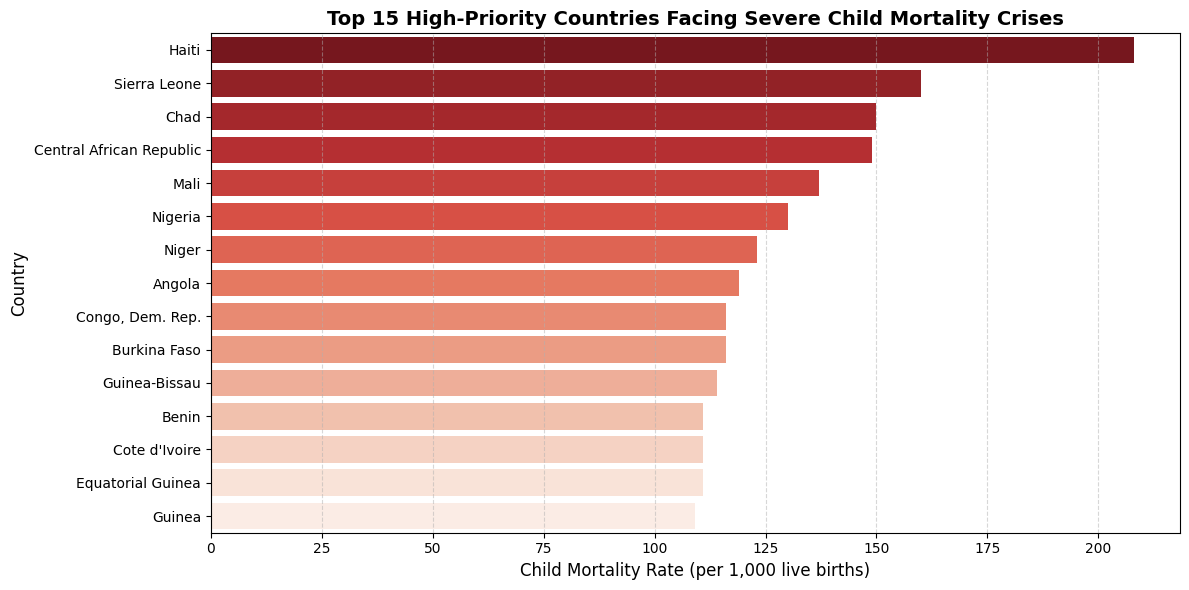

In [20]:
# 1. Filter for the high-priority group (Cluster 1)
high_risk_countries = df[df['kmeans_cluster'] == 1].copy()

# 2. Sort them by highest child mortality and lowest income to find the most vulnerable
high_risk_sorted = high_risk_countries.sort_values(
    by=['child_mort', 'income'],
    ascending=[False, True]
)

# 3. Print the top 10 most critical countries in a clean list
print("--- TOP 10 HIGHEST PRIORITY COUNTRIES FOR HELP INTERNATIONAL ---")
print(high_risk_sorted[['country', 'child_mort', 'income', 'gdpp']].head(10).to_string(index=False))

# 4. Plot a bar chart showing the worst-hit countries by Child Mortality
plt.figure(figsize=(12, 6))
sns.barplot(
    data=high_risk_sorted.head(15), # Looking at the top 15 most critical
    x='child_mort',
    y='country',
    hue = 'country',
    legend = False,
    palette='Reds_r'
)

plt.title('Top 15 High-Priority Countries Facing Severe Child Mortality Crises', fontsize=14, fontweight='bold')
plt.xlabel('Child Mortality Rate (per 1,000 live births)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **Assignment 3 ✅**